In [22]:
!pip install xgboost

In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv("filtered_hpc_dataset.csv")

In [25]:
df.head()

,Unnamed: 0,JobID,SubmitTime,RequestedTime,RunTime,AllocatedProcessors,RequestedProcessors,UsedMemory,RequestedMemory,requestedMemory_per_cpu
0,3023,7019,4796419,43200,12322,16,16,57344.0,972800.0,60800.0
1,3048,7047,4851035,43200,452,16,16,57344.0,972800.0,60800.0
2,4110,26226,6745127,36000,6,16,16,409600.0,409600.0,25600.0
3,4116,26253,6759830,90000,60107,8,8,409600.0,409600.0,51200.0
4,4222,26537,6855164,60,1,120,120,921600.0,921600.0,7680.0


In [26]:
copy_data = df.drop(columns="Unnamed: 0", axis=1)

In [27]:
copy_data.head()

,JobID,SubmitTime,RequestedTime,RunTime,AllocatedProcessors,RequestedProcessors,UsedMemory,RequestedMemory,requestedMemory_per_cpu
0,7019,4796419,43200,12322,16,16,57344.0,972800.0,60800.0
1,7047,4851035,43200,452,16,16,57344.0,972800.0,60800.0
2,26226,6745127,36000,6,16,16,409600.0,409600.0,25600.0
3,26253,6759830,90000,60107,8,8,409600.0,409600.0,51200.0
4,26537,6855164,60,1,120,120,921600.0,921600.0,7680.0


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
relation_matrix = copy_data.corr()

<Axes: >

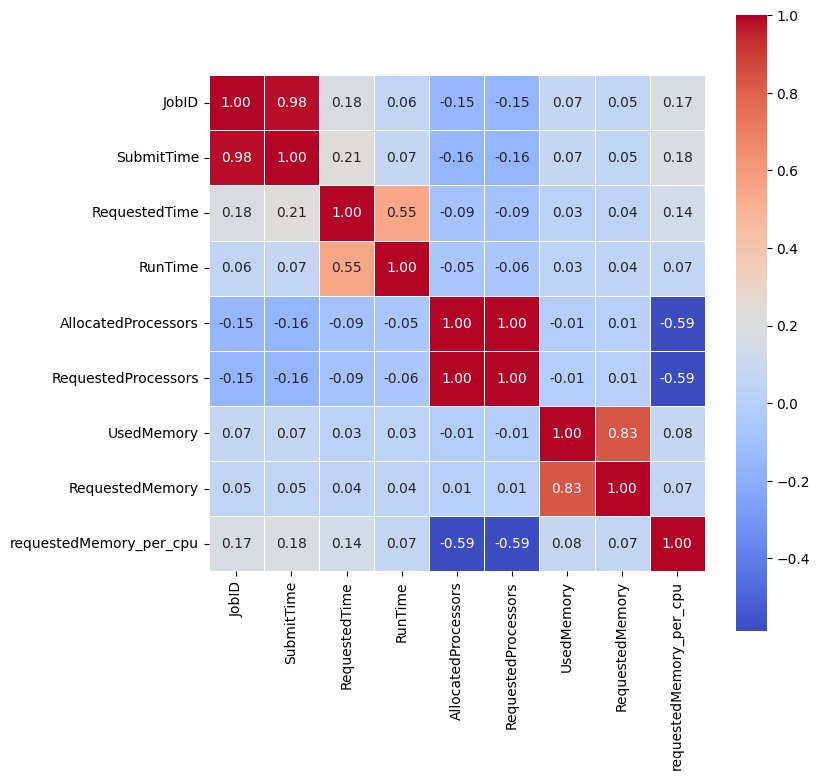

In [30]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    relation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    square=True
)

## predicting "usedMemory"

hence dropping "runtime" column


In [31]:
memory_df = copy_data.drop("RunTime", axis=1)
memory_df.head()

,JobID,SubmitTime,RequestedTime,AllocatedProcessors,RequestedProcessors,UsedMemory,RequestedMemory,requestedMemory_per_cpu
0,7019,4796419,43200,16,16,57344.0,972800.0,60800.0
1,7047,4851035,43200,16,16,57344.0,972800.0,60800.0
2,26226,6745127,36000,16,16,409600.0,409600.0,25600.0
3,26253,6759830,90000,8,8,409600.0,409600.0,51200.0
4,26537,6855164,60,120,120,921600.0,921600.0,7680.0


In [32]:
# splitting the data

from sklearn.model_selection import train_test_split

X = memory_df.drop(columns="UsedMemory", axis=1)
y = memory_df["UsedMemory"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [33]:
# scailing the values

from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

In [34]:
X_train

,JobID,SubmitTime,RequestedTime,AllocatedProcessors,RequestedProcessors,RequestedMemory,requestedMemory_per_cpu
151010,407305,89282154,21600,1,1,409600.0,409600.0
55807,276705,45634121,600,4,4,409600.0,102400.0
18417,150403,23240289,86400,2,2,409600.0,204800.0
2938,64148,10416573,54000,8,8,409600.0,51200.0
151526,407863,89431230,1200,1,1,409600.0,409600.0
...,...,...,...,...,...,...,...
119879,369435,74487890,43200,4,4,512000.0,128000.0
103694,352113,67326520,432000,1,1,409600.0,409600.0
131932,385423,78841202,600,8,8,716800.0,89600.0
146867,402392,87888210,15540,1,1,409600.0,409600.0


In [35]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_scaled)

decision_model = DecisionTreeRegressor()
decision_model.fit(X_train_scaled, y_train_scaled)

xgb_model = XGBRegressor()
xgb_model.fit(X_train_scaled, y_train_scaled)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
# accuracy of the model

linear_pred = linear_model.predict(X_test_scaled)
decision_pred = decision_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

linear_mse = mean_squared_error(y_test_scaled, linear_pred)
decision_mse = mean_squared_error(y_test_scaled, decision_pred)
xgb_mse = mean_squared_error(y_test_scaled, xgb_pred)

print("Linear Regression MSE:", linear_mse)
print("Decision Tree Regression MSE:", decision_mse)
print("XGBoost Regression MSE:", xgb_mse)

Linear Regression MSE: 0.3190914824053941
Decision Tree Regression MSE: 0.1462354254736307
XGBoost Regression MSE: 0.13419295186014818


In [39]:
# model score

linear_score = linear_model.score(X_test_scaled, y_test_scaled)
decision_score = decision_model.score(X_test_scaled, y_test_scaled)
xgb_score = xgb_model.score(X_test_scaled, y_test_scaled)

print("Linear Regression Score:", linear_score)
print("Decision Tree Regression Score:", decision_score)
print("XGBoost Regression Score:", xgb_score)


Linear Regression Score: 0.6603347239606887
Decision Tree Regression Score: 0.8443358757626706
XGBoost Regression Score: 0.8571548018376791


In [47]:
y_test.head()

,UsedMemory
22252,409600.0
29496,409600.0
37908,409600.0
46373,409600.0
107951,409600.0


In [49]:
# table with actual values and predicted values
# actual values after inverse scaling

y_test_actual = y_scaler.inverse_transform(y_test_scaled)
xgb_actual = xgb_model.predict(X_test_scaled)
xgb_actual = y_scaler.inverse_transform(xgb_actual.reshape(-1, 1))
linear_actual = linear_model.predict(X_test_scaled)
linear_actual = y_scaler.inverse_transform(linear_actual.reshape(-1, 1))
decision_actual = decision_model.predict(X_test_scaled)
decision_actual = y_scaler.inverse_transform(decision_actual.reshape(-1, 1))





In [58]:
final_vlaues = pd.DataFrame(columns=["actual", "xgb", "linear", "decision"])

In [59]:
final_vlaues["actual"] = y_test_actual.flatten()
final_vlaues["xgb"] = xgb_actual.flatten()
final_vlaues["linear"] = linear_actual.flatten()
final_vlaues["decision"] = decision_actual.flatten()

In [60]:
final_vlaues.head()

,actual,xgb,linear,decision
0,409600.0,409804.03125,410596.582823,409600.0
1,409600.0,409549.87500,409896.214481,409600.0
2,409600.0,409170.18750,409185.951660,409600.0
3,409600.0,408974.12500,409474.677733,409600.0
4,409600.0,409413.34375,411023.301127,409600.0
